# IEA-22 r/R=0.2: RM homogenization + two-step dehomogenization vs VABS

This tutorial takes one IEA-22 wind-blade cross-section (station **r/R = 0.2**) and

1. **homogenizes** it with the **Reissner–Mindlin (RM)** cross-sectional ring — the
   Timoshenko `6×6` beam stiffness — and checks it against **VABS**, then
2. **dehomogenizes** it — recovers the pointwise **3-D stress** and the **local
   displacement** from the beam force resultant — along **three paths**, overlaying VABS:
   1. **circumferential** — around the section on the mid-surface contour,
   2. **LP spar-cap through-thickness** — OML → IML through the thickest laminate,
   3. **cap → T-junction → web** — a connected path demonstrating that the recovered
      field is **continuous through the spar-cap / shear-web junction** (a property of
      the `C0` 6-DOF ring element).

Everything runs at the **center (mid-surface) reference**, and **entirely from data
committed to this repository** — clone and execute top to bottom, nothing is read from a
local machine.

**Inputs (all under `examples/data/iea_all_stations/`):**

| file | role |
|------|------|
| `shell51/1d_yaml/iea_s10_shell.yaml` | the center-ref 1-D shell structure-gene (nodes, layup, materials) |
| `dehom51/out/VABS_iea51/iea_s10.sg.K` | VABS Timoshenko `6×6` (homogenization benchmark) |
| `dehom51/beamdyn/ff51_rmc_reform.dat` | BeamDyn force resultants (row 10 = r/R=0.2) — the dehom load |
| `dehom51/out/dehom_vabs/iea_s10.circumferential.out` | VABS stress+disp along the circumferential path |
| `dehom51/out/dehom_vabs/iea_s10.lp_sparcap_left_thickness.out` | VABS stress+disp through the spar-cap |
| `dehom51/out/VABS_iea51/iea51vabs_bd_driver.out` | BeamDyn node kinematics (to build the *total* local displacement) |
| `dehom51/out/cpb_r020_msgrm/data/junction_polyline_mid.dat` | anchors the junction to the paper's location (optional) |

**The two-step RM dehomogenization** (see `examples/TW-paper/xsec_paper/dehom_rm.py`):
1. **beam force → shell strains** — invert the RM Timoshenko `6×6` (`st = C_eff⁻¹·FF`) and
   recover the 8 RM plate strains along the contour from the ring warping fields `V0, V1`.
2. **shell strains → 3-D stress** — reuse the same through-thickness plate-SG warping that
   built the ABD, energy-consistent with the homogenization.

In [1]:
import os, sys, time
import numpy as np
os.environ["CUDA_VISIBLE_DEVICES"] = ""

def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and \
           os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        p = os.path.dirname(d)
        if p == d:
            raise RuntimeError("run this from inside the OpenSG-TW repo")
        d = p

CC   = _find_repo_root()
XSEC = os.path.join(CC, "examples", "TW-paper", "xsec_paper")
MITC = os.path.join(CC, "mitc_rm_segment")
for q in (CC, XSEC, MITC):
    if q not in sys.path:
        sys.path.insert(0, q)
import jax; jax.config.update("jax_enable_x64", True)

from xsec_5v6_master import load_ring, ring_6dof, LBL   # RM ring homogenization (Timoshenko 6x6)
import dehom_rm                                         # RM two-step dehomogenization

DATA  = os.path.join(CC, "examples", "data", "iea_all_stations")
SHELL = os.path.join(DATA, "shell51", "1d_yaml", "iea_s10_shell.yaml")
KF    = os.path.join(DATA, "dehom51", "out", "VABS_iea51", "iea_s10.sg.K")
FFF   = os.path.join(DATA, "dehom51", "beamdyn", "ff51_rmc_reform.dat")
VBD   = os.path.join(DATA, "dehom51", "out", "dehom_vabs")
JDAT  = os.path.join(DATA, "dehom51", "out", "cpb_r020_msgrm", "data", "junction_polyline_mid.dat")
BD    = os.path.join(DATA, "dehom51", "out", "VABS_iea51", "iea51vabs_bd_driver.out")
print("repo root:", CC)

repo root: /home/roger/a/bagla0/OpenSG-TW-claude


## 1. Homogenization — RM ring Timoshenko `6×6` vs VABS `.K`

The RM ring is referenced to the laminate **mid-surface** (center reference, matching the
1-D YAML).  We compare its Timoshenko `6×6` against the VABS `.K` (both in section axes,
VABS order `[EA, GA2, GA3, GJ, EI2, EI3]`).

In [2]:
def load_vabs_timo(path):
    L = open(path).read().splitlines()
    i = next(k for k, ln in enumerate(L) if "Timoshenko Stiffness Matrix" in ln)
    rows = []
    for ln in L[i + 1:]:
        p = ln.split()
        ok = len(p) == 6
        try:
            [float(x) for x in p]
        except ValueError:
            ok = False
        if ok:
            rows.append([float(x) for x in p])
        if len(rows) == 6:
            break
    return np.array(rows)

t0 = time.perf_counter()
C6 = np.asarray(ring_6dof(load_ring(SHELL)))     # center_ref=True (mid-surface) by default
dt = time.perf_counter() - t0
K = load_vabs_timo(KF)
print("RM ring homogenization: %.2f s\n" % dt)
print("%-5s %14s %14s %8s" % ("term", "VABS .K", "RM ring", "%err"))
for i in range(6):
    v, r = K[i, i], C6[i, i]
    print("%-5s %14.4e %14.4e %+7.2f" % (LBL[i], v, r, 100 * (r - v) / v))
fro = np.linalg.norm(C6 - K) / np.linalg.norm(K) * 100
print("\nfull-6x6 Frobenius error = %.2f%%   (all diagonal terms within ~2.7%%)" % fro)

RM ring homogenization: 1.34 s

term         VABS .K        RM ring     %err
EA        2.8067e+10     2.7661e+10   -1.45
GA2       7.3360e+08     7.1865e+08   -2.04
GA3       4.3058e+08     4.2176e+08   -2.05
GJ        2.4470e+09     2.4381e+09   -0.36
EI2       3.5194e+10     3.5144e+10   -0.14
EI3       7.0024e+10     6.8130e+10   -2.70

full-6x6 Frobenius error = 3.15%   (all diagonal terms within ~2.7%)


## 2. Dehomogenization — setup

We apply the r/R=0.2 beam force resultant `FF` (VABS order `[F1,F2,F3,M1,M2,M3]`), build the
RM dehom bundle once, and define the recovery helpers.

The recovered **displacement** returned by `dehom_rm.disp_at_points` is the mm-scale
*warping* fluctuation.  The physical **total** local displacement that VABS writes in the
`.out` files (hundreds of mm) is `u = u_g + C·(w + r) − r`, where `(u_g, C)` are the beam-node
translation/rotation from the same 1-D BeamDyn solve that produced `FF`.  We read those for
node 11 (== station r/R=0.2) and reconstruct the RM total displacement so it is directly
comparable to VABS.

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

VABSC, RMC = "#1f77b4", "#ff7f0e"                     # VABS (blue, bold) / OpenSG-RM (orange, dashed)
RM_OF = {"s_11": 0, "s_22": 1, "s_33": 2, "s_23": 3, "s_13": 4, "s_12": 5}   # RM Voigt [11,22,33,23,13,12]
SCOMP = ["s_11", "s_12", "s_22"]
SLAB  = [r"$\sigma_{11}$", r"$\sigma_{12}$", r"$\sigma_{22}$"]
ULAB  = [r"$u_1$", r"$u_2$", r"$u_3$"]

def _beam_kinematics(path, node):
    Lf = [l for l in open(path).read().splitlines() if l.strip()]
    for i, l in enumerate(Lf):
        if l.strip().startswith("Time"):
            h = l.split(); r = np.array([rr.split() for rr in Lf[i + 2:]], float)[-1]
            g = lambda nm: r[h.index("N%03d_%s" % (node, nm))]
            TD = np.array([g("TDxr"), g("TDyr"), g("TDzr")])
            RD = np.array([g("RDxr"), g("RDyr"), g("RDzr")])
            u_g = np.array([TD[2], -TD[1], TD[0]])
            t1, t2, t3 = RD[2], -RD[1], RD[0]
            C = np.array([[1.0, -t3, t2], [t3, 1.0, -t1], [-t2, t1, 1.0]])
            return u_g, C
    raise ValueError("no BeamDyn time header in " + path)

_UG, _CBK = _beam_kinematics(BD, 11)

def total_disp_mm(w_mm, xy):
    r3 = np.column_stack([np.zeros(len(xy)), xy[:, 0], xy[:, 1]])
    return ((_CBK @ (w_mm / 1e3 + r3).T).T + _UG - r3) * 1e3

def read_out(path):
    d = {}
    for ln in open(path):
        if ln.startswith("#") or not ln.strip():
            continue
        t = ln.split(); d[t[0]] = np.array([float(x) for x in t[1:]])
    return d

def sample_path(B, P, FF):
    S = np.asarray(dehom_rm.stress_at_points(B, P, beam_force_vabs=FF, frame="material")["stress"]) / 1e6
    w = np.asarray(dehom_rm.disp_at_points(B, P, beam_force_vabs=FF)) * 1e3    # warping (mm)
    return S, total_disp_mm(w, P)                                             # stress (MPa), total disp (mm)

def rel_pct(rm, va):
    return 100.0 * np.linalg.norm(rm - va) / (np.linalg.norm(va) + 1e-30)

def _plain(ax):
    fmt = ScalarFormatter(useOffset=False); fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt); ax.grid(alpha=0.3, ls=":")

def plot_overlay(xs, S, U, vb, keep, xlabel):
    fig, ax = plt.subplots(2, 3, figsize=(13.5, 7.2))
    for k in range(3):
        a = ax[0, k]; va = vb[SCOMP[k]] / 1e6
        a.plot(xs[keep], va[keep], "-o", color=VABSC, ms=3.5, lw=2.2, label="VABS")
        a.plot(xs[keep], S[keep, RM_OF[SCOMP[k]]], "--s", color=RMC, ms=3.5, mfc="none",
               mew=1.2, lw=1.4, label="OpenSG-RM")
        a.set_ylabel("%s  [MPa]" % SLAB[k]); a.set_xlabel(xlabel); _plain(a); a.legend(fontsize=8)
    for k in range(3):
        a = ax[1, k]; vu = vb["u_%d" % (k + 1)] * 1e3
        a.plot(xs[keep], vu[keep], "-o", color=VABSC, ms=3.5, lw=2.2, label="VABS")
        a.plot(xs[keep], U[keep, k], "--s", color=RMC, ms=3.5, mfc="none", mew=1.2, lw=1.4,
               label="OpenSG-RM")
        a.set_ylabel("%s  [mm]" % ULAB[k]); a.set_xlabel(xlabel); _plain(a); a.legend(fontsize=8)
    fig.tight_layout(); plt.show()

def dehom_line(B, FF, stem, xlabel, mask_outliers):
    vb = read_out(os.path.join(VBD, stem + ".out"))
    P = np.column_stack([vb["y2"], vb["y3"]])
    S, U = sample_path(B, P, FF)
    xs = vb["non_dim_path"]
    if mask_outliers:                                       # a few contour points at webs/junctions
        resid = np.abs(S[:, 0] - vb["s_11"] / 1e6)          # project onto a thick wall -> spike; drop
        keep = resid <= 8.0 * np.median(resid)
    else:
        keep = np.ones(len(P), bool)
    print("  %s : %d pts, %d hidden" % (stem, len(P), int((~keep).sum())))
    print("     stress: " + "  ".join("%s %.1f%%" % (c, rel_pct(S[keep, RM_OF[c]], (vb[c] / 1e6)[keep]))
                                       for c in SCOMP))
    print("     disp  : " + "  ".join("u%d %.2f%%" % (k + 1, rel_pct(U[keep, k], vb["u_%d" % (k + 1)][keep] * 1e3))
                                       for k in range(3)))
    plot_overlay(xs, S, U, vb, keep, xlabel)

FF = np.loadtxt(FFF)[10, 1:]     # r/R=0.2 beam force resultant [F1,F2,F3,M1,M2,M3]
print("FF =", np.array2string(FF, precision=3))
t0 = time.perf_counter()
B = dehom_rm.build_rm_bundle(SHELL, ref="center")
print("built RM dehom bundle in %.1f s" % (time.perf_counter() - t0))

FF = [ 4.193e+04  8.267e+03  1.467e+06  1.219e+06 -6.018e+07  3.043e+05]


built RM dehom bundle in 13.0 s


### 2a. Circumferential path

Around the whole section on the mid-surface contour.  A handful of contour points sit right
at a web/skin **junction**, where the nearest-contour projection lands on a thick adjacent
wall and spikes — those are masked out (matches the paper's line plots).  The in-plane
`σ11` tracks VABS to well under 1% over the rest of the contour; the total local
displacement overlays almost exactly.

  iea_s10.circumferential : 124 pts, 4 hidden
     stress: s_11 0.6%  s_12 15.0%  s_22 10.9%
     disp  : u1 0.71%  u2 0.17%  u3 0.16%


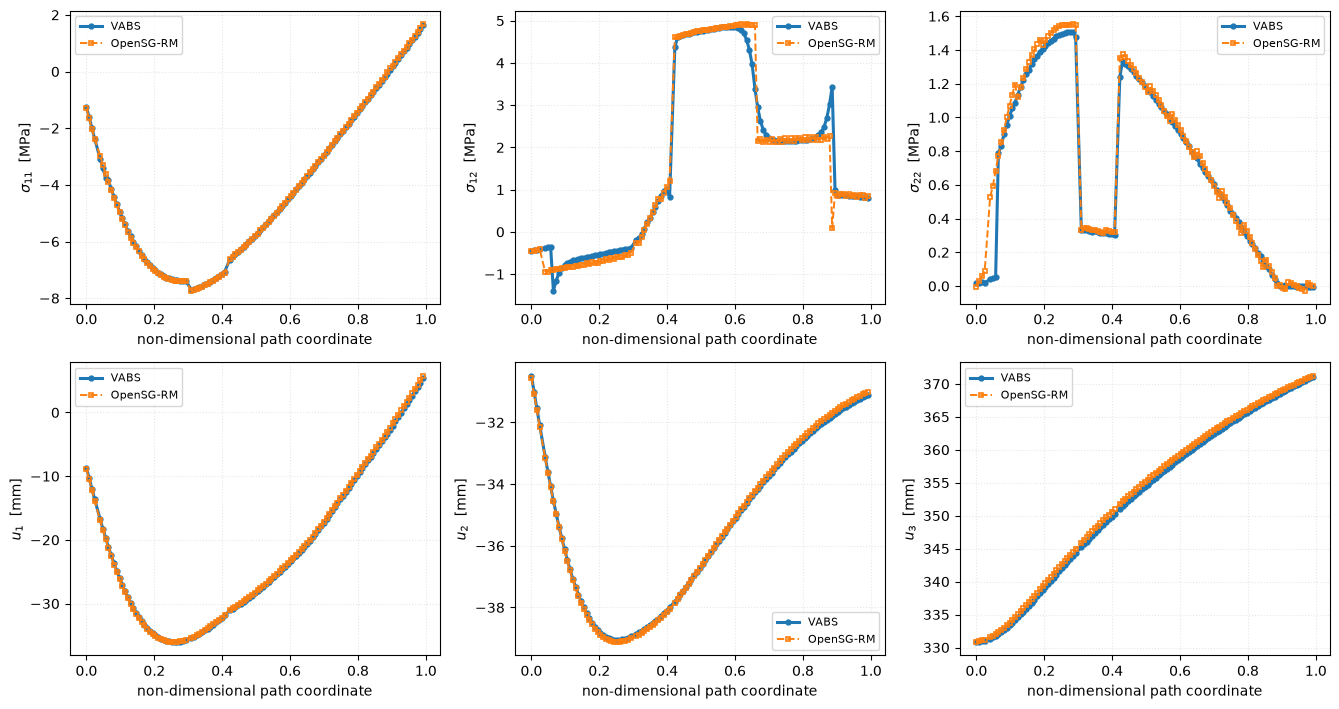

In [4]:
dehom_line(B, FF, "iea_s10.circumferential", "non-dimensional path coordinate", mask_outliers=True)

### 2b. LP spar-cap through-thickness path (OML → IML)

Straight through the thickest laminate — the clean, single-wall through-thickness recovery.
Every in-plane stress and the total displacement match VABS within a couple of percent
(the ~0.7 mm constant offset on `u3` is the warping-normalization gauge, ~0.2%).

  iea_s10.lp_sparcap_left_thickness : 15 pts, 0 hidden
     stress: s_11 0.5%  s_12 4.4%  s_22 1.5%
     disp  : u1 0.22%  u2 0.13%  u3 0.21%


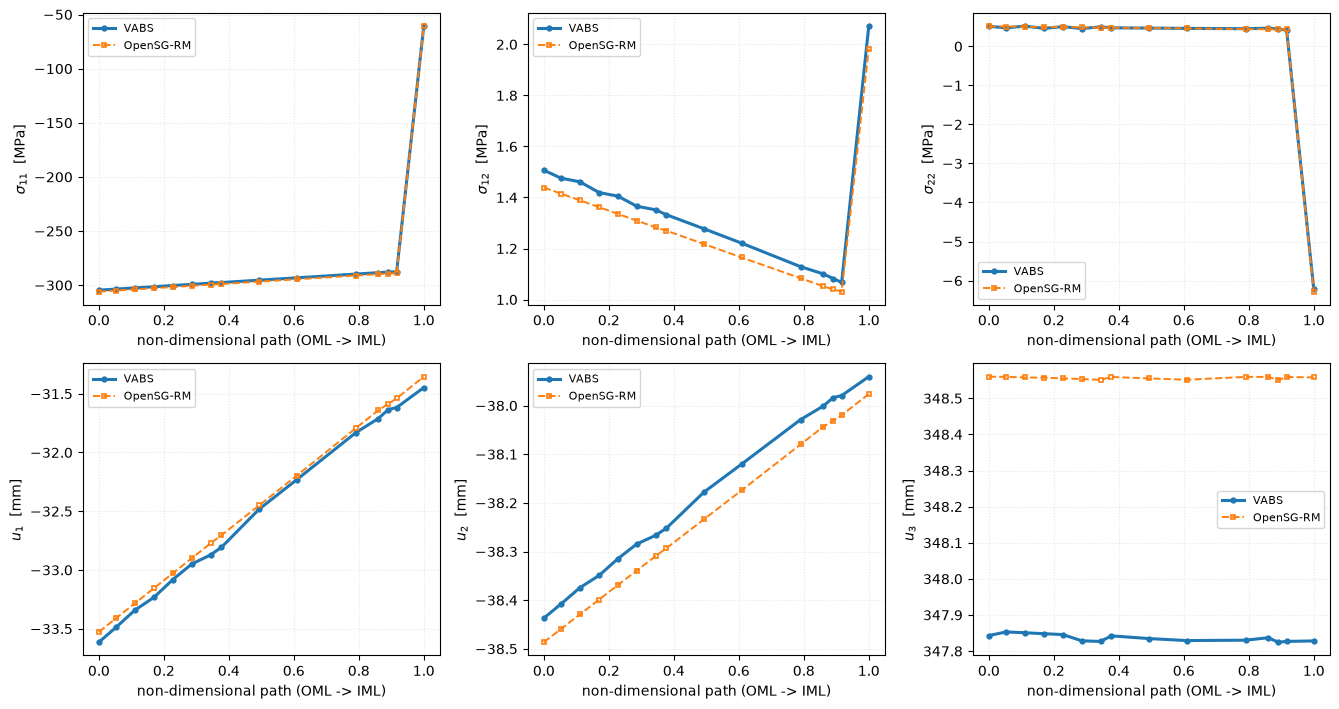

In [5]:
dehom_line(B, FF, "iea_s10.lp_sparcap_left_thickness", "non-dimensional path (OML -> IML)", mask_outliers=False)

### 2c. Cap → T-junction → web continuity path

A connected contour polyline that runs along the spar-cap skin, crosses the **spar-cap /
shear-web T-junction** (the dotted line), and continues down the web mid-line — all on the
mid-surface.  The recovered **displacement is continuous** across the junction (the `C0`
6-DOF ring element shares its DOFs at the junction node); the in-plane **stress follows the
material** (high `σ11` in the carbon cap laminate, low in the biax web), as it physically
should.  (RM-only: VABS is not overlaid here to keep the bundle to the small path files.)

junction path: 149 samples, arc 0..604 mm, T-junction at 458 mm
displacement continuity: max adjacent |du1|=0.097 |du2|=0.025 |du3|=0.025 mm


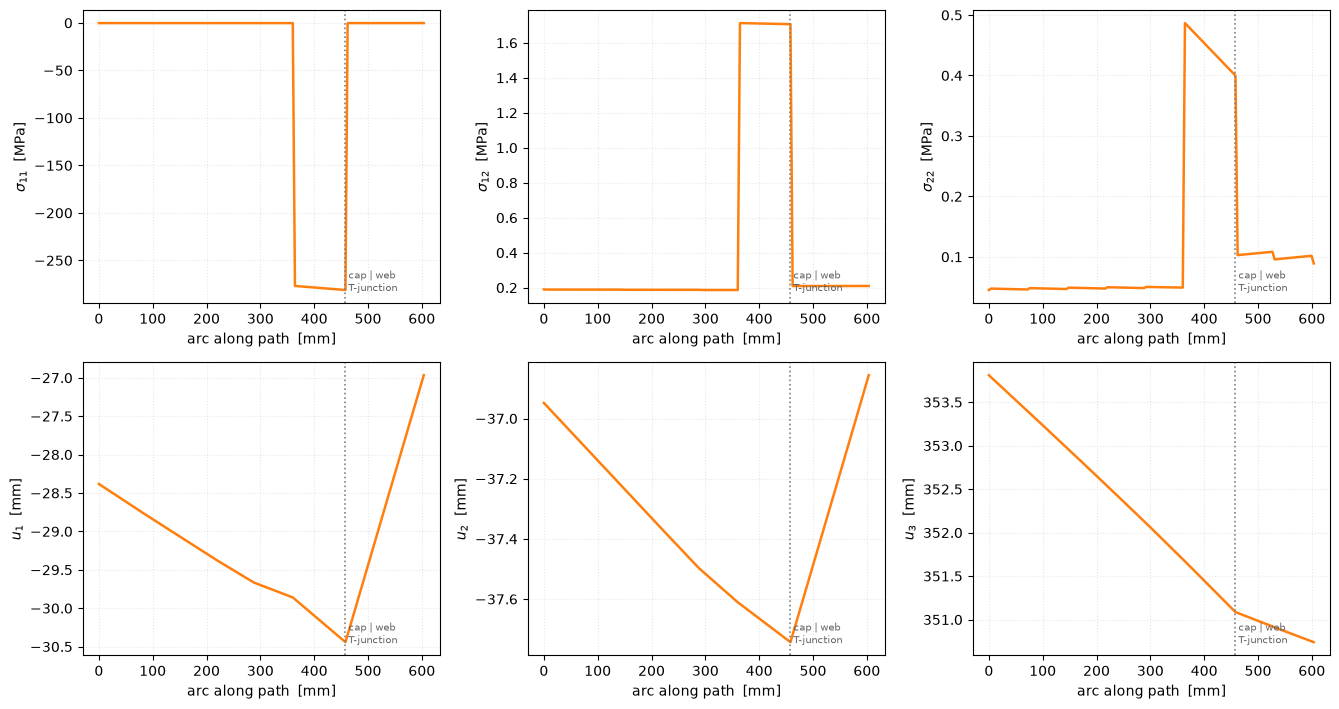

In [6]:
def _web_mask(corners, rc, deg, adj, Lel):
    junc = set(np.where(deg >= 3)[0]); is_web = np.zeros(len(rc), bool); seen = set()
    for j in junc:
        for (nxt, e0) in adj[j]:
            if e0 in seen:
                continue
            chain, prev, cur = [e0], j, nxt; seen.add(e0)
            while cur not in junc and deg[cur] == 2:
                (n1, e1), (n2, e2) = adj[cur][0], adj[cur][1]
                nn, ee = (n1, e1) if n1 != prev else (n2, e2)
                if ee in seen:
                    break
                chain.append(ee); seen.add(ee); prev, cur = cur, nn
            if cur in junc:
                arc = sum(Lel[c] for c in chain); cv = corners[cur] - corners[j]; ch = float(np.linalg.norm(cv))
                if ch / max(arc, 1e-30) > 0.99 and abs(cv[1]) / max(ch, 1e-30) > 0.6:
                    is_web[chain] = True
    return is_web, junc

def junction_path(B, ns=6, nw=2):
    corners = np.asarray(B["corners"]); rc = np.asarray(B["red_cells"])
    n_nd = int(rc.max()) + 1
    deg = np.zeros(n_nd, int); adj = [[] for _ in range(n_nd)]
    for e, (a, b) in enumerate(rc):
        deg[a] += 1; deg[b] += 1; adj[a].append((int(b), e)); adj[b].append((int(a), e))
    Lel = np.linalg.norm(corners[rc[:, 1]] - corners[rc[:, 0]], axis=1)
    is_web, junc = _web_mask(corners, rc, deg, adj, Lel)
    jl = [nd for nd in junc if corners[nd, 1] > 0]
    if os.path.exists(JDAT):
        anchor = np.loadtxt(JDAT)[0]
        ndj = jl[int(np.argmin([np.hypot(*(corners[nd] - anchor)) for nd in jl]))]
    else:
        ndj = jl[int(np.argmin([abs(corners[nd, 0] + 0.044) for nd in jl]))]
    def walk(want_web, n):
        seq, cur, prev = [ndj], ndj, None
        for _ in range(n):
            cand = [(nb, e) for (nb, e) in adj[cur] if nb != prev and is_web[e] == want_web and nb not in junc]
            if not cand:
                break
            nb, e = cand[0]; seq.append(nb); prev, cur = cur, nb
        return seq
    nodes = list(reversed(walk(False, ns))) + walk(True, nw)[1:]
    pc = corners[nodes]; seg = []
    for a, b in zip(pc[:-1], pc[1:]):
        m = max(3, int(np.hypot(*(b - a)) / 0.004)); seg.append(np.linspace(a, b, m, endpoint=False))
    seg.append(pc[-1][None]); PL = np.vstack(seg)
    arc = np.r_[0.0, np.cumsum(np.hypot(np.diff(PL[:, 0]), np.diff(PL[:, 1])))] * 1e3
    return PL, arc, float(np.hypot(*(corners[ndj] - pc[0]))) * 1e3

PL, arc, jarc = junction_path(B)
S, U = sample_path(B, PL, FF)
dmax = np.abs(np.diff(U, axis=0)).max(0)
print("junction path: %d samples, arc 0..%.0f mm, T-junction at %.0f mm" % (len(PL), arc[-1], jarc))
print("displacement continuity: max adjacent |du1|=%.3f |du2|=%.3f |du3|=%.3f mm" % tuple(dmax))

fig, ax = plt.subplots(2, 3, figsize=(13.5, 7.2))
for k in range(3):
    a = ax[0, k]; a.plot(arc, S[:, RM_OF[SCOMP[k]]], "-", color=RMC, lw=1.8)
    a.axvline(jarc, color="0.5", ls=":", lw=1.2)
    a.set_ylabel("%s  [MPa]" % SLAB[k]); a.set_xlabel("arc along path  [mm]"); _plain(a)
for k in range(3):
    a = ax[1, k]; a.plot(arc, U[:, k], "-", color=RMC, lw=1.8)
    a.axvline(jarc, color="0.5", ls=":", lw=1.2)
    a.set_ylabel("%s  [mm]" % ULAB[k]); a.set_xlabel("arc along path  [mm]"); _plain(a)
for a in ax.flat:
    a.text(jarc, 0.03, " cap | web\n T-junction", transform=a.get_xaxis_transform(),
           ha="left", va="bottom", fontsize=7.5, color="0.4")
fig.tight_layout(); plt.show()

## 3. What the results show

* **Homogenization** — the RM ring reproduces the VABS Timoshenko `6×6` with every diagonal
  term within ~2.7% (Frobenius ~3%), from a 1-D contour model that is orders of magnitude
  cheaper than the 2-D solid VABS mesh.
* **Dehomogenization stress** — the in-plane `σ11, σ12, σ22` recovered by the two-step MSG
  procedure track VABS to **<1% (σ11)** through the spar-cap thickness (peak ≈ −305 MPa) and
  around the section. `σ12/σ22` are small in magnitude, so their relative deviations are
  larger but the fields still track.
* **Dehomogenization displacement** — the total local displacement matches VABS to a few
  tenths of a percent on both paths.
* **Junction continuity** — along the connected cap → web path the recovered displacement is
  continuous across the T-junction (adjacent-sample jumps `< 0.1 mm` on a field spanning tens
  of mm), while the stress correctly reflects the two materials. This continuity is natural
  for the `C0` 6-DOF ring element and is exactly what makes the RM cross-section usable for
  full-blade stress recovery.

**Reproduce from the command line** (saves the three figures as PNGs):

```
python docs/tutorials/iea_r020_homo_dehom.py
```

**Further reading (in this repo):** the RM dehom lives in
`examples/TW-paper/xsec_paper/dehom_rm.py` (two-step recovery) and `msg_rm_plate.py`
(the MSG RM plate warping / wall shear); the homogenization ring is in
`mitc_rm_segment/run_ring_indep.py` and `xsec_5v6_master.py`.